In [41]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, BaseMessage, AIMessage
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from dotenv import load_dotenv
from langgraph.graph.message import add_messages
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver

In [42]:
LLM = ChatGroq(model="openai/gpt-oss-safeguard-20b", temperature=0.3)

In [43]:
class chatstate(TypedDict):
    messages : Annotated[list[BaseMessage], add_messages ]

In [44]:
def chat_node(state: chatstate):
    #all the details are given inside as a dictionary which frontend is required
    decision = interrupt({
        "type":"approval",
        "reason": "Model is about  to answer a user question.",
        "question": state["messages"][-1].content,
        "instruction": "Approve this question? yes/no"
    })
    
    # we have now the decision of user in the decision variable send by the frontend(dictinary)
    if decision["approved"] == 'no':
        return {"messages": [AIMessage(content="Not approved.")]}
    
    #else sent it to llm and save it 
    else:
        response = LLM.invoke(state["messages"])
        return {"messages": [response]}

In [45]:
#building the graph

graph = StateGraph(chatstate)

# preparig the nodes
graph.add_node("chat_node", chat_node)

# edges
graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

#puuting a check pointer
checkpointer = MemorySaver()  # storing in ram

chatbot = graph.compile(checkpointer=checkpointer)

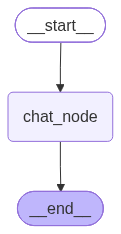

In [46]:
from IPython.display import Image
Image(chatbot.get_graph().draw_mermaid_png())

In [47]:
# since we have a checkpointer we need a thread
config = {"configurable": {"thread_id": '1234'}}


# step1 user asks a question
initial_state = {
    "messages" : [HumanMessage(content="explain about the ancient egyption king tut in 10 lines.")]
}

# invoking the graph for the first time 
result = chatbot.invoke(initial_state, config=config)

In [48]:
result

{'messages': [HumanMessage(content='explain about the ancient egyption king tut in 10 lines.', additional_kwargs={}, response_metadata={}, id='52d3714f-7f48-484b-b8e0-b9cc828c5049')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about  to answer a user question.', 'question': 'explain about the ancient egyption king tut in 10 lines.', 'instruction': 'Approve this question? yes/no'}, id='86fdc4746e2068bef20aba7cbd49df9e')]}

In [49]:
# now from result we will take the interrupt
message = result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about  to answer a user question.',
 'question': 'explain about the ancient egyption king tut in 10 lines.',
 'instruction': 'Approve this question? yes/no'}

In [50]:
#now will go to frontend and give this message to user and safe it in user_input
user_input = input(f"\n backend message - {message} \n Approve this question? (y/n): ")

In [51]:
# now we will give this back to the graph that is reinvoke with command
final_result =  chatbot.invoke(
    Command(resume={"approved": user_input}),
    config=config,
)

In [52]:
final_result

{'messages': [HumanMessage(content='explain about the ancient egyption king tut in 10 lines.', additional_kwargs={}, response_metadata={}, id='52d3714f-7f48-484b-b8e0-b9cc828c5049'),
  AIMessage(content='1. **Tutankhamun** (c.\u202f1341–1325\u202fBCE) was a pharaoh of the 18th Dynasty, ascending the throne at about 8\u202fyears old.  \n2. He succeeded his father, **Akhenaten**, and is best known for restoring the traditional polytheistic religion after Akhenaten’s monotheistic experiment.  \n3. Tutankhamun’s reign was brief—roughly 12\u202fyears—yet he is famed for his elaborate burial and the wealth of his tomb.  \n4. In 1922, British archaeologist **Howard Carter** discovered his nearly intact tomb (KV62) in the Valley of the Kings, sparking worldwide fascination.  \n5. The tomb’s treasures include the iconic gold **death mask**, a throne, chariots, and a vast array of funerary artifacts.  \n6. Radiocarbon dating and DNA analysis suggest Tutankhamun was a relative of his predecessor,